Image Processing

In [1]:
# Installing Libraries
import sys, subprocess, pkgutil

def pip_install(pkg):
    if pkg in {m.name for m in pkgutil.iter_modules()}:
        return
    print(f"Installing {pkg}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# Core extras
for _pkg in ["opencv-python", "tqdm", "pytorch-fid", "piq"]:
    try:
        pip_install(_pkg)
    except Exception as e:
        print(f"⚠️ Could not auto-install {_pkg}: {e}")

Installing opencv-python...
Installing pytorch-fid...


In [2]:
# Importing Libraries
import os
import csv
import shutil
import random
from pathlib import Path

import numpy as np
from PIL import Image

import cv2  # after install
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.utils import save_image, make_grid
from torchvision.datasets import ImageFolder

import matplotlib.pyplot as plt

In [3]:
# Creating Folders
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

# RAW data (source .tif files)
SOURCE_FOLDER = Path("BBC020_v1_outlines_cells")

# Working root
TEST_ROOT = Path("Test")
CLEANED_FOLDER = TEST_ROOT / "Cleaned"
CROPPED_FOLDER = TEST_ROOT / "Cleaned_Cropped"
GAN_DATA_ROOT = TEST_ROOT / "gan_data"
GAN_CLASS_DIR = GAN_DATA_ROOT / "cells"  # for ImageFolder

for p in [TEST_ROOT, CLEANED_FOLDER, CROPPED_FOLDER, GAN_CLASS_DIR]:
    p.mkdir(parents=True, exist_ok=True)


In [4]:
# Removing Corrupted Images
def is_corrupted(image_path: Path) -> bool:
    try:
        with Image.open(image_path) as im:
            im.verify() 
        return False
    except Exception:
        return True


def is_noisy(img: Image.Image, threshold: float = 100.0) -> bool:
    """Use Laplacian variance to detect low-detail / very smooth images.
    Lower variance -> less high-frequency detail -> treated as 'noisy/bad'.
    Tune threshold empirically.
    """
    gray = np.array(img.convert("L"))
    lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    return lap_var < threshold


def center_crop_safe(img: Image.Image, target_w: int, target_h: int, pad_color=(0,0,0)) -> Image.Image:
    """Center-crop to target size. If target bigger than image, pad instead of clipping.
    Returns an image exactly (target_w, target_h).
    """
    w, h = img.size
    if target_w <= w and target_h <= h:
        # simple crop
        left = (w - target_w) // 2
        top = (h - target_h) // 2
        right = left + target_w
        bottom = top + target_h
        return img.crop((left, top, right, bottom))
    # need pad
    canvas = Image.new("RGB", (target_w, target_h), pad_color)
    # scale? we choose paste centered without scaling
    paste_x = (target_w - w) // 2
    paste_y = (target_h - h) // 2
    canvas.paste(img, (paste_x, paste_y))
    return canvas


In [5]:
# Copying all images into 'Test'
for file in SOURCE_FOLDER.glob("*.tif"):
    shutil.copy(file, TEST_ROOT / file.name)


In [6]:
# Calling functions to clean up dataset
valid_images = []  
image_sizes = []   

print("\n🔍 Scanning .tif files in Test/ ...")
for file in tqdm(list(TEST_ROOT.glob("*.tif"))):
    if is_corrupted(file):
        continue
    try:
        with Image.open(file) as img:
            img = img.convert("RGB")
            if is_noisy(img):
                continue
            png_name = file.with_suffix(".png").name
            png_path = CLEANED_FOLDER / png_name
            img.save(png_path)
            valid_images.append(png_path)
            image_sizes.append(img.size)
    except Exception as e:
        print(f"❌ Error with {file.name}: {e}")



🔍 Scanning .tif files in Test/ ...


0it [00:00, ?it/s]


In [7]:
# Calculating Average Dimensions
if image_sizes:
    avg_width = int(np.mean([w for w, h in image_sizes]))
    avg_height = int(np.mean([h for w, h in image_sizes]))
    print(f"📏 Average crop size: {avg_width} x {avg_height}")
else:
    print("🚫 No valid images found. Using default crop size 64x64.")
    avg_width, avg_height = 64, 64


🚫 No valid images found. Using default crop size 64x64.


In [8]:
# Saving Cropped Images 
for i, file_path in enumerate(valid_images):
    with Image.open(file_path) as img:
        cropped = center_crop_safe(img, avg_w, avg_h)
        save_path = CROPPED_FOLDER / f"cell_{i:05d}.png"
        cropped.save(save_path)

In [9]:
# Deleting .tif and .png images from 'Test'
for file in TEST_ROOT.glob("*.tif"):
    file.unlink()


In [10]:
# Preparing compatible dataset directory
use_symlinks = True

# Clean any existing
for p in GAN_CLASS_DIR.glob("*"):
    p.unlink()

for src in CROPPED_FOLDER.glob("*.png"):
    dst = GAN_CLASS_DIR / src.name
    if use_symlinks:
        try:
            if dst.exists():
                dst.unlink()
            os.symlink(src.resolve(), dst)
        except Exception:
            shutil.copy(src, dst)
    else:
        shutil.copy(src, dst)

In [11]:
# Dataset + Dataloader for DCGAN
image_size = 64  # DCGAN default (can raise to 128 if GPU OK)
batch_size = 32

transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # RGB
])

dataset = ImageFolder(root=str(GAN_DATA_ROOT), transform=transform)
print(f"Dataset size: {len(dataset)} images")

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)


Dataset size: 296 images


In [12]:
# DCGAN Architecture
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3, feature_g=64):
        super().__init__()
        self.net = nn.Sequential(
            # input Z latent vector (z_dim) going into a convolution
            nn.ConvTranspose2d(z_dim, feature_g * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_g * 8),
            nn.ReLU(True),

            # state size: (feature_g*8) x 4 x 4
            nn.ConvTranspose2d(feature_g * 8, feature_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g * 4),
            nn.ReLU(True),
            # (feature_g*4) x 8 x 8

            nn.ConvTranspose2d(feature_g * 4, feature_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g * 2),
            nn.ReLU(True),
            # (feature_g*2) x 16 x 16

            nn.ConvTranspose2d(feature_g * 2, feature_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_g),
            nn.ReLU(True),
            # (feature_g) x 32 x 32

            nn.ConvTranspose2d(feature_g, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()  # output [-1,1]
            # img_channels x 64 x 64
        )

    def forward(self, x):
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self, img_channels=3, feature_d=64):
        super().__init__()
        self.net = nn.Sequential(
            # input: img_channels x 64 x 64
            nn.Conv2d(img_channels, feature_d, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (feature_d) x 32 x 32

            nn.Conv2d(feature_d, feature_d * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (feature_d*2) x 16 x 16

            nn.Conv2d(feature_d * 2, feature_d * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # (feature_d*4) x 8 x 8

            nn.Conv2d(feature_d * 4, feature_d * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_d * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # (feature_d*8) x 4 x 4

            nn.Conv2d(feature_d * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()  # scalar probability
        )

    def forward(self, x):
        return self.net(x)


def weights_init_dcgan(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [13]:
# Instantiate Models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

z_dim = 100
G = Generator(z_dim=z_dim).to(device)
D = Discriminator().to(device)

G.apply(weights_init_dcgan)
D.apply(weights_init_dcgan)

criterion = nn.BCELoss()
lr = 0.0002
beta1 = 0.5

G_opt = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
D_opt = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

real_label = 1.
fake_label = 0.

Using device: cpu


In [ ]:
# Traning Model
epochs = 50
fixed_noise = torch.randn(64, z_dim, 1, 1, device=device)

G_losses = []
D_losses = []

for epoch in range(epochs):
    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        # --- Train D ---
        D.zero_grad(set_to_none=True)
        labels = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        output = D(real_imgs).view(-1)
        loss_D_real = criterion(output, labels)
        loss_D_real.backward()

        noise = torch.randn(b_size, z_dim, 1, 1, device=device)
        fake_imgs = G(noise)
        labels.fill_(fake_label)
        output = D(fake_imgs.detach()).view(-1)
        loss_D_fake = criterion(output, labels)
        loss_D_fake.backward()
        D_opt.step()

        # --- Train G ---
        G.zero_grad(set_to_none=True)
        labels.fill_(real_label)  # generator wants D to say real
        output = D(fake_imgs).view(-1)
        loss_G = criterion(output, labels)
        loss_G.backward()
        G_opt.step()

    D_loss_epoch = (loss_D_real + loss_D_fake).item()
    G_loss_epoch = loss_G.item()
    D_losses.append(D_loss_epoch)
    G_losses.append(G_loss_epoch)

    # sample grid every 10 epochs
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            fake = G(fixed_noise).detach().cpu()
        save_image(fake, TEST_ROOT / f"generated_epoch_{epoch+1}.png", normalize=True)

print("Training complete.")



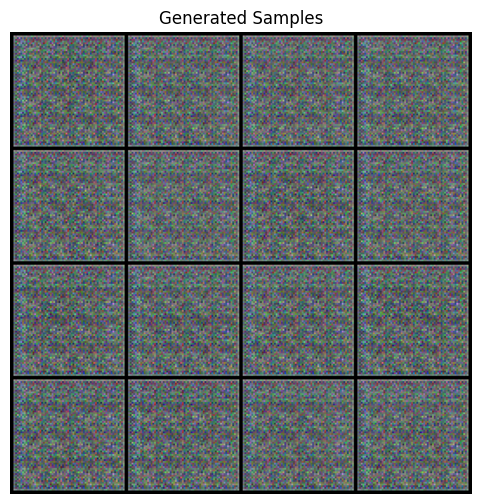

In [ ]:
# Visualising Samples from Generator
with torch.no_grad():
    samples = G(torch.randn(16, z_dim, 1, 1, device=device)).cpu()

grid = make_grid(samples, nrow=4, normalize=True)
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.axis("off")
plt.title("Generated Samples")
plt.show()

In [ ]:
# Saving Generated Images for FID
real_dir = TEST_ROOT / "fid_real"
fake_dir = TEST_ROOT / "fid_fake"
real_dir.mkdir(exist_ok=True)
fake_dir.mkdir(exist_ok=True)

# Clear dirs
for p in real_dir.glob("*"): p.unlink()
for p in fake_dir.glob("*"): p.unlink()

# Save up to N real images (post-transform) from dataloader for FID.
N_FID = 500
saved = 0
for imgs, _ in dataloader:
    for img in imgs:
        # Denormalize to [0,1]
        img_dn = (img * 0.5) + 0.5
        save_image(img_dn, real_dir / f"real_{saved:05d}.png")
        saved += 1
        if saved >= N_FID:
            break
    if saved >= N_FID:
        break
print(f"Saved {saved} real images for FID.")

# Save fake images
G.eval()
saved = 0
with torch.no_grad():
    while saved < N_FID:
        remain = min(batch_size, N_FID - saved)
        noise = torch.randn(remain, z_dim, 1, 1, device=device)
        fake = G(noise).cpu()
        fake_dn = (fake * 0.5) + 0.5
        for j in range(fake_dn.size(0)):
            save_image(fake_dn[j], fake_dir / f"fake_{saved:05d}.png")
            saved += 1
print(f"Saved {saved} fake images for FID.")

Saved 296 real images for FID.
Saved 500 fake images for FID.


In [ ]:
# Compute FID
try:
    from pytorch_fid.fid_score import calculate_fid_given_paths
    import torch
    fid_val = calculate_fid_given_paths([str(real_dir), str(fake_dir)], batch_size=50, device=device, dims=2048)
    print(f"FID: {fid_val:.4f}")
except Exception as e:
    print("⚠️ Could not compute FID programmatically; try shell command below.")
    print(e)
    print("You can run in a notebook cell: !python -m pytorch_fid Test/fid_real Test/fid_fake")


Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /Users/akshaj/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:13<00:00, 7.11MB/s]
  0%|          | 0/6 [00:00<?, ?it/s]OMP: Error #15: Initializing libomp.dylib, but found libomp.dylib already initialized.
OMP: Hint This means that multiple copies of the OpenMP runtime have been linked into the program. That is dangerous, since it can degrade performance or cause incorrect results. The best thing to do is to ensure that only a single OpenMP runtime is linked into the process, e.g. by avoiding static linking of the OpenMP runtime in any library. As an unsafe, unsupported, undocumented workaround you can set the environment variable KMP_DUPLICATE_LIB_OK=TRUE to allow the program to continue to execute, but that may cause crashes or silently produce incorrect results. For more information, please see http://openmp.llvm.org/
  0%|          | 0/6 [00:00<?, ?it/s]

⚠️ Could not compute FID programmatically; try shell command below.
DataLoader worker (pid(s) 20256) exited unexpectedly
You can run in a notebook cell: !python -m pytorch_fid Test/fid_real Test/fid_fake


In [ ]:
try:
    import piq  # PyTorch Image Quality library
    _HAS_PIQ = True
except ImportError:
    _HAS_PIQ = False
    print("⚠️ PIQ library not found. Install with: pip install piq")

if _HAS_PIQ:
    import glob
    import torch
    from PIL import Image
    from torchvision import transforms
    from piq import ssim
    import numpy as np

    # Real and fake image directories
    real_paths = sorted(glob.glob(str(real_dir / '*.png')))
    fake_paths = sorted(glob.glob(str(fake_dir / '*.png')))
    n_pairs = min(len(real_paths), len(fake_paths), 100)  # limit to 100 pairs

    # Transform
    tf = transforms.Compose([
        transforms.Resize(image_size),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
    ])

    ssims = []
    for i in range(n_pairs):
        r = tf(Image.open(real_paths[i]).convert('RGB')).unsqueeze(0).to(device)
        f = tf(Image.open(fake_paths[i]).convert('RGB')).unsqueeze(0).to(device)
        s = ssim(r, f, data_range=1.0)  # from piq
        ssims.append(s.item())

    print(f"✅ Avg SSIM over {n_pairs} pairs: {np.mean(ssims):.4f} ± {np.std(ssims):.4f}")
else:
    print("⚠️ piq not available; skipping SSIM evaluation.")


✅ Avg SSIM over 100 pairs: 0.0007 ± 0.0009


In [ ]:
# Save datset
manifest_csv = TEST_ROOT / "dataset_manifest.csv"
with open(manifest_csv, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["index", "filename", "width", "height"])
    for i, src in enumerate(CROPPED_FOLDER.glob("*.png")):
        with Image.open(src) as im:
            w,h = im.size
        writer.writerow([i, src.name, w, h])